In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
# mouse brain MLCB version 
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

# human muscle 
#input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'

# mouse muscle 
#input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"

#cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
# 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
# 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes") #celltypes=cell_types

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  16206
Number of junctions after removing singletons:  16203
The number of unique cell types in the data is:  9
The number of unique cells in the data is:  7856
The number of unique junctions in the data is:  16204
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
The number of junctions in the data is:  15942
The number of cells in the data is:  7856
The number of cell types in the data is:  9


In [5]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7856
7856


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [10]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [11]:
cluster_counts

<7856x15942 sparse matrix of type '<class 'numpy.int64'>'
	with 10597973 stored elements in COOrdinate format>

In [12]:
26109676 / (4989*131669)

0.039747007931495874

In [13]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.9153789267535754


## Evaluate performance on imputation/masking task

In [14]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [15]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.1001, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.05
The seed is:  132314


[10543608   975088  2661982  4444465  6741095 10403537  9395310  8379495
  5163799  1597757  2553650  5175361  3080997 10235461  6351118  2373196
  4376795  3694824  1767431  9149060  9384034  9268594  4600157  2780394
  5331873  1610569  7938558  3810511  8013132  8636182  1376069   236252
  2422038  5847646  2361045  2264591  5192447   207865  3821320  9115794
  9969629  5545141  9603589  2524223  2189382  8084214  4479151  8486644
  3277944  8606690]
Number of entries (junction-cell pairs) masked:  529898.0
The masking percentage is: 0.1
The seed is:  958706
[ 7395356  3776609  7553335  6611116  5109942   855611  1754079   196520
  1201703  1909645  2877991  3326300  1826591  6615812  7336370  6054998
  1957009  9841841  4016431   764149  6086443  7484614 10270448  8865676
  5222664  8669462  9471265  1568106  9483818   642729  9594527  2576067
   951995   462191  9346998  3524561  8268595  5585553  1787209  4581918
  3504163  9166174  3144505  6617831  8621916  7633776  1734557  60

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:139: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.1
The masking percentage is: 0.1001
The masking percentage is: 0.2


In [16]:
# Now can run factor model on masked data
Ks = [10, 20, 100, 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 43, 44]

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=70, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 10
------------------------------------------------
The masking percentage is: 0.05
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 42
Define the guide
Fit the model
Epoch 0, Loss: 250457919.96392083
Epoch 10, Loss: 235613491.07353395
Epoch 20, Loss: 221770251.3063101
Epoch 30, Loss: 209352588.86835173
Epoch 40, Loss: 197881207.918262
Epoch 50, Loss: 187540372.8737386
Epoch 60, Loss: 177802587.987526
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 43
Define the guide
Fit the model
Epoch 0, Loss: 251921522.00795478
Epoch 10, Loss: 237099804.1002944
Epoch 20, Loss: 223352191.25281176
Epoch 30, Loss: 210936019.6682502
Epoch 40, Loss: 199683416.30701908
Epoch 50, Loss: 188799058.42992526
Epoch 60, Loss: 179294411.16149652
Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 44
Define the guid

In [17]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

Calculating performance for K = 10 and masking percentage = 0.05


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.3221711421228275
Spearman correlation:  0.3420503356199159
L2 error:  0.14386884421883087
RMSE:  0.37930046693726976
L1 error:  0.32133603262747196
Spearman correlation:  0.34829964299985056
L2 error:  0.1431537792459659
RMSE:  0.37835668257077987
L1 error:  0.32210334285434405
Spearman correlation:  0.33583117882272423
L2 error:  0.14446126266510467
RMSE:  0.38008060022198537
Calculating performance for K = 10 and masking percentage = 0.1
L1 error:  0.32221809193577594
Spearman correlation:  0.341892676027267
L2 error:  0.14390577072072785
RMSE:  0.3793491409252535
L1 error:  0.32139024836645974
Spearman correlation:  0.3481561380831737
L2 error:  0.14319428719845786
RMSE:  0.3784102102196211
L1 error:  0.3221491090820312
Spearman correlation:  0.3356811463459348
L2 error:  0.14449299210522037
RMSE:  0.38012233834019854
Calculating performance for K = 10 and masking percentage = 0.1001
L1 error:  0.3222347551901899
Spearman correlation:  0.3417372742300349
L2 error:  0.14

In [18]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])
# save to csv
masked_perf_df.to_csv("masked_perf_df.csv")

#### Make plots 

In [19]:
masked_perf_df.head()

,seed,l1,r,l2,rmse,K,perc_masked,J,num_epochs
0,42,0.322171,0.342050,0.143869,0.379300,10,0.05,15942,70
1,43,0.321336,0.348300,0.143154,0.378357,10,0.05,15942,70
2,44,0.322103,0.335831,0.144461,0.380081,10,0.05,15942,70
3,42,0.322218,0.341893,0.143906,0.379349,10,0.10,15942,70
4,43,0.321390,0.348156,0.143194,0.378410,10,0.10,15942,70


In [20]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

42_0.05      4
43_0.05      4
44_0.05      4
42_0.1       4
43_0.1       4
44_0.1       4
42_0.1001    4
43_0.1001    4
44_0.1001    4
42_0.2       4
43_0.2       4
44_0.2       4
Name: seed_perc_masked, dtype: int64

In [21]:
masked_perf_df[masked_perf_df["seed"] == 42].l1.unique()

array([0.32217114, 0.32221809, 0.32223476, 0.32298184, 0.3211104 ,
       0.32117142, 0.32118745, 0.32207585, 0.32047463, 0.32054559,
       0.32055835, 0.32160738, 0.32051153, 0.32061537, 0.32062707,
       0.32174913])

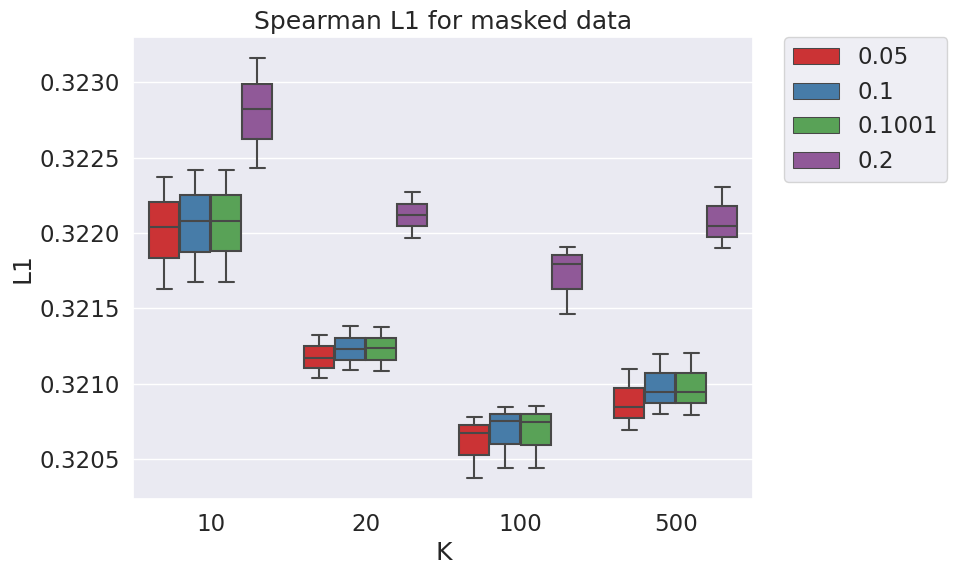

0.32037245615449766


In [46]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())


#### Variation in performance mainly stems from which seed used for training model 

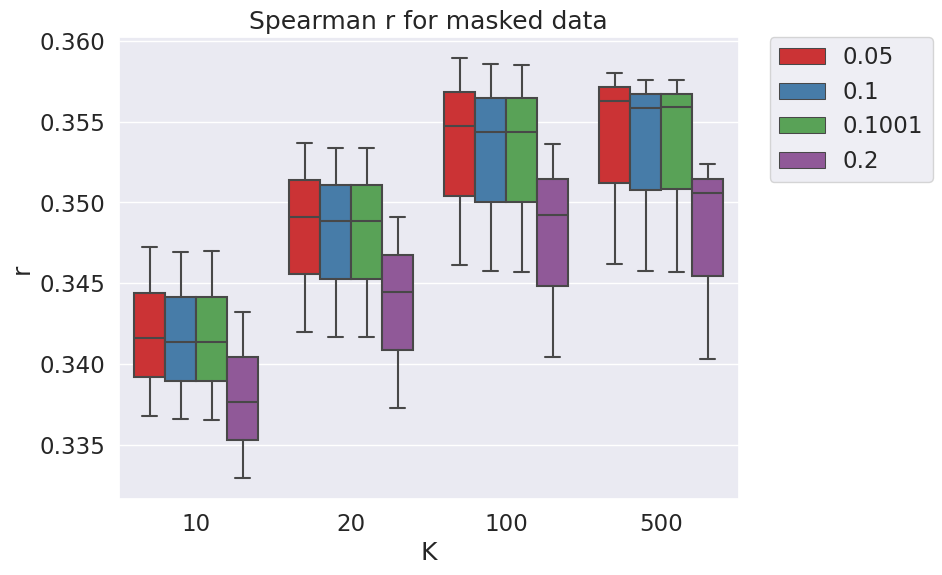

0.3589352093245085


In [48]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

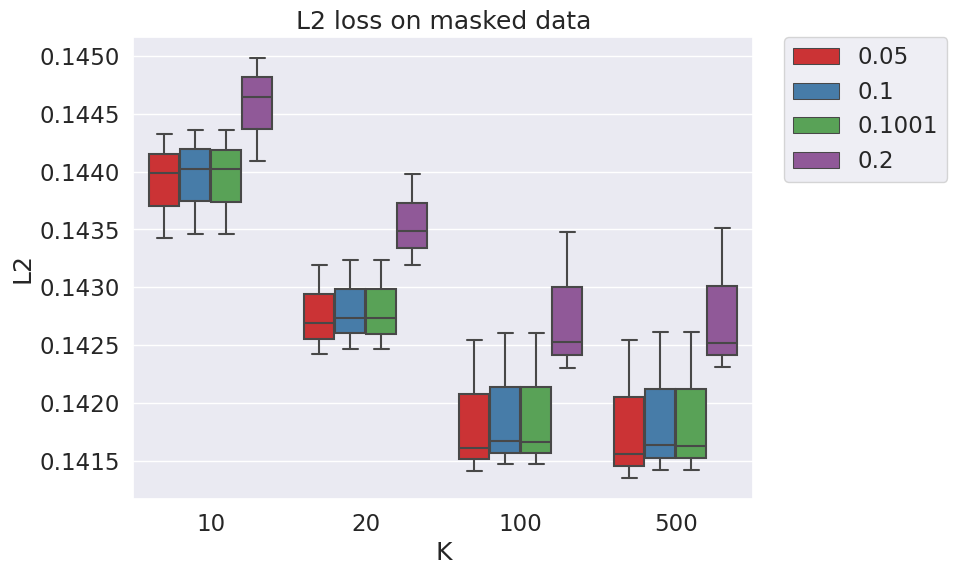

0.3589352093245085


In [49]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l2", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L2")
ax.set_title("L2 loss on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

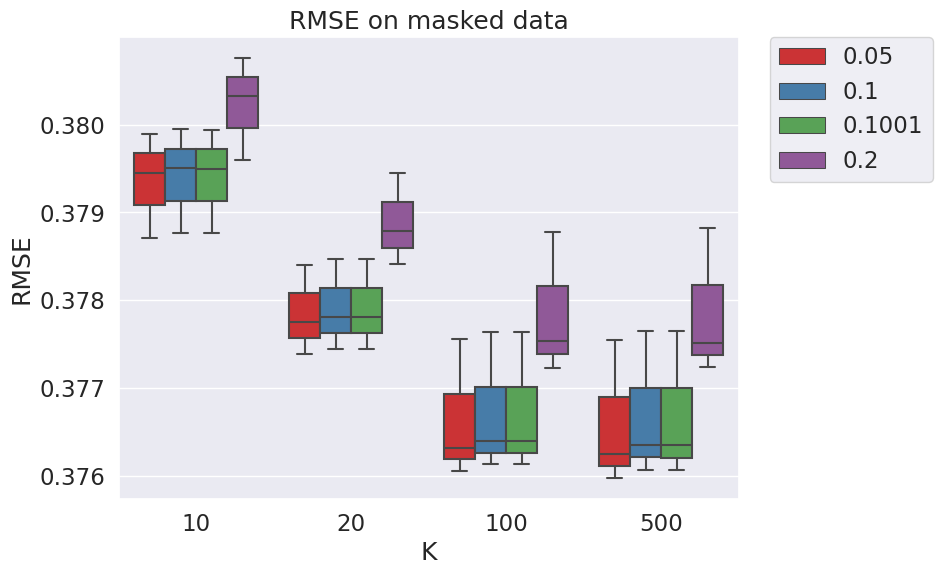

0.37596932727637444


In [50]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

In [52]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()
median_rmse = masked_perf_df.groupby(["K"])["rmse"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

# find K that gives the lowest rmse and print it
min_rmse = median_rmse.idxmin()
print("The K that gives the lowest median rmse is: " + str(min_rmse))

The K that gives the lowest median l1 error is: 100
The K that gives the lowest median l2 error is: 500
The K that gives the highest median r is: 500
The K that gives the lowest median rmse is: 500


## Run full factor model! 

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 3816
Define the guide
Fit the model
Epoch 0, Loss: 263576886.8904473
Epoch 10, Loss: 248048011.61218837
Epoch 20, Loss: 233700579.0301884
Epoch 30, Loss: 220515806.5448326
Epoch 40, Loss: 208530418.1604608
Epoch 50, Loss: 197456043.95210472
Epoch 60, Loss: 187537746.40053496
Epoch 70, Loss: 178231083.9243745
Epoch 80, Loss: 169586576.05685404
Epoch 90, Loss: 161599648.4002517
Epoch 100, Loss: 154169948.4194487
Epoch 110, Loss: 147096082.0186026
Epoch 120, Loss: 140249446.9479375
Epoch 130, Loss: 133937705.03552966
Epoch 140, Loss: 127723837.14024176
Epoch 150, Loss: 121970327.78455888
Epoch 160, Loss: 116408908.63478777
Epoch 170, Loss: 111174308.12509777
Epoch 180, Loss: 106445140.62330571
Epoch 190, Loss: 101988181.87772618
Epoch 200, Loss: 97790811.06606758
Epoch 210, Loss: 94142982.14141126
Epoch 220, Loss: 90913699.96493712
Epoch 230, Loss: 

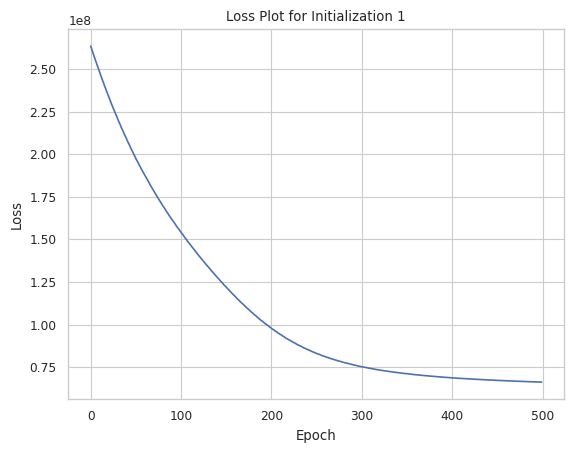

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [110]:
reload(factor_model)
best_K = 20 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, K=K, lr=0.01, loss_plot=True, num_epochs=500, save_to_file = False)

In [111]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

conc = latent_vars["conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

[4.5175195 3.142478  1.76636   ... 1.2386525 2.0186384 1.966395 ]
[2.552624  2.8167346 1.8926508 ... 4.1672955 1.8464233 1.3685036]
The inferred concentration parameter is: 13.625701
The inferred pi parameter is: [0.02642969 0.02852723 0.02378615 0.0339781  0.02282277 0.02308524
 0.04845061 0.02149018 0.5241737  0.01844407 0.01812021 0.02242747
 0.01812662 0.0232926  0.02970204 0.05021836 0.02492857 0.01486172
 0.01260972 0.01452497]


### Evaluate latent variables 

In [112]:
cell_ids_conversion

,cell_id_index,cell_id,cell_type
0,0,A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
1041,1,A14-MAA000930-3_8_M-1-1_Brain_Non-Myeloid_brai...,Brain_Non-Myeloid_brain_pericyte
2047,2,A14-MAA000947-3_9_M-1-1_Brain_Non-Myeloid_brai...,Brain_Non-Myeloid_brain_pericyte
2699,3,A15-MAA000561-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
3895,4,A19-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...,Brain_Non-Myeloid_brain_pericyte
...,...,...,...
6228162,7851,P7-MAA000564-3_10_M-1-1_Brain_Non-Myeloid_astr...,Brain_Non-Myeloid_astrocyte
6228482,7852,P7-MAA000947-3_9_M-1-1_Brain_Non-Myeloid_astro...,Brain_Non-Myeloid_astrocyte
6228625,7853,P8-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_astr...,Brain_Non-Myeloid_astrocyte
6229049,7854,P9-MAA000930-3_8_M-1-1_Brain_Non-Myeloid_astro...,Brain_Non-Myeloid_astrocyte


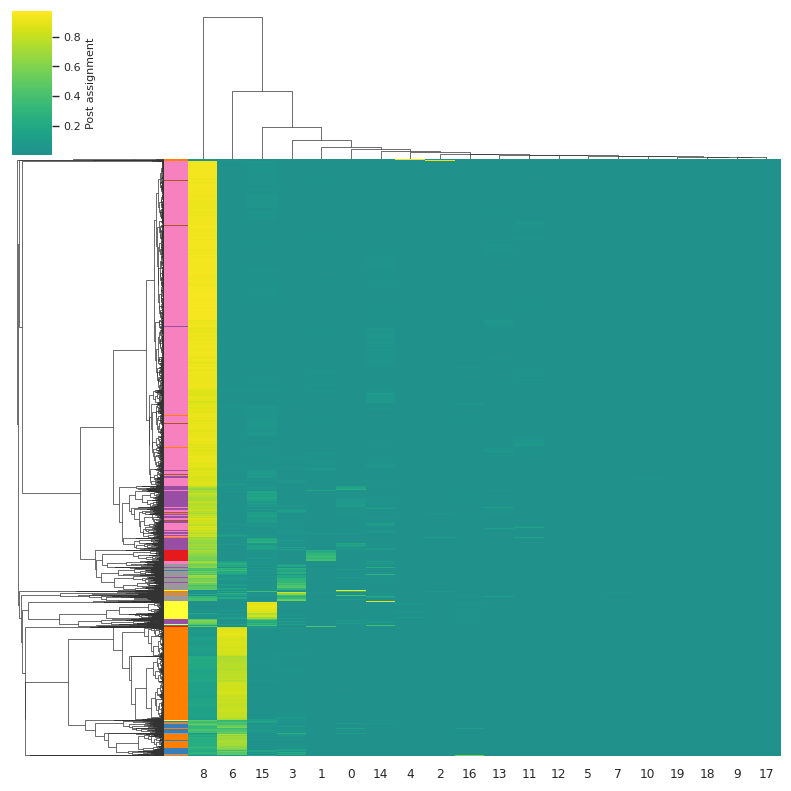

In [113]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [114]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

The silhouette score for K = 20 is: 0.10618371
The Davies Bouldin score for K = 20 is: 4.851881752135141


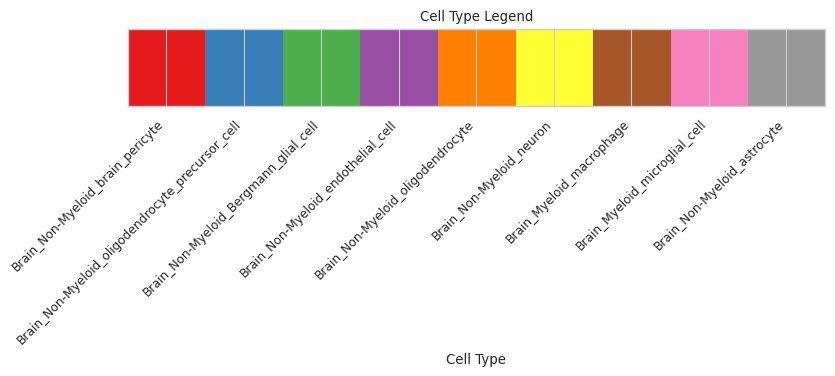

In [115]:
# print cell type color legend seperately
import matplotlib.pyplot as plt

cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [116]:
# make UMAP using average assign_post across seeds and color points by cell_type 
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

/scratch/ipykernel_56906/177290916.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

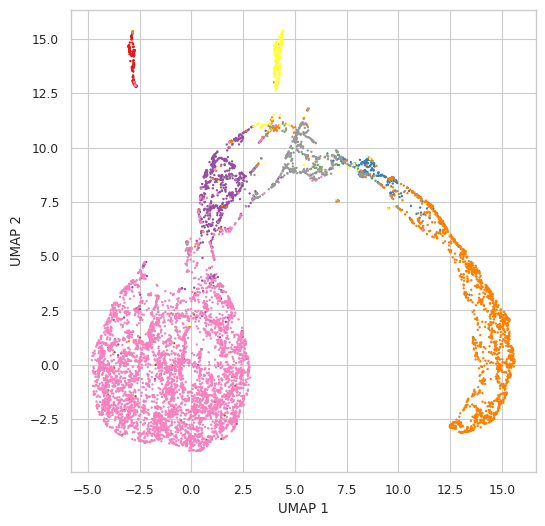

In [117]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

([<matplotlib.axis.XTick at 0x7f295cc4ad60>,
 [Text(0, 0, 'Brain_Non-Myeloid_brain_pericyte'),
  Text(1, 0, 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'),
  Text(2, 0, 'Brain_Non-Myeloid_Bergmann_glial_cell'),
  Text(3, 0, 'Brain_Non-Myeloid_endothelial_cell'),
  Text(4, 0, 'Brain_Non-Myeloid_oligodendrocyte'),
  Text(5, 0, 'Brain_Non-Myeloid_neuron'),
  Text(6, 0, 'Brain_Myeloid_macrophage'),
  Text(7, 0, 'Brain_Myeloid_microglial_cell'),
  Text(8, 0, 'Brain_Non-Myeloid_astrocyte')])

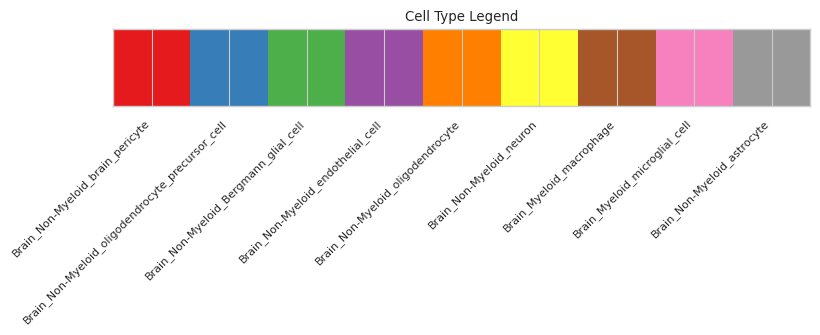

In [118]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

[0.76233757 0.14811254 0.04499916 0.01465466 0.00952814 0.00540528
 0.00378391 0.00247619 0.00182978 0.00132539]


/scratch/ipykernel_56906/2178371379.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

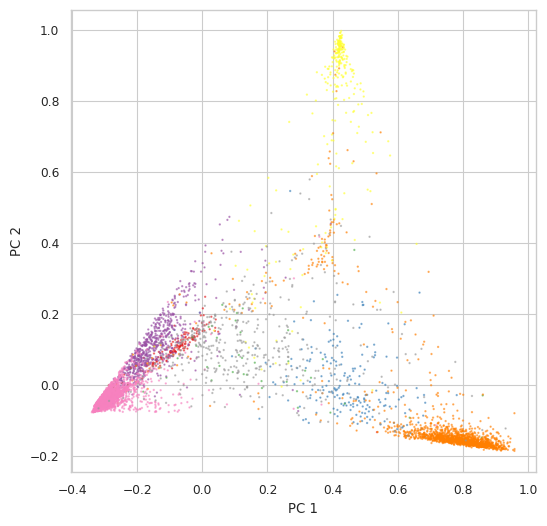

In [119]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

import pandas as pd

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [120]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df


,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15,Factor 16,Factor 17,Factor 18,Factor 19
Brain_Non-Myeloid_brain_pericyte,0.004063,0.295354,0.001627,0.002678,0.001748,0.001666,0.012294,0.005010,0.616007,0.000654,0.000894,0.001400,0.000966,0.000811,0.002599,0.046501,0.004552,0.000321,0.000225,0.000632
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.007187,0.002132,0.002826,0.072351,0.002954,0.002012,0.469955,0.001604,0.333511,0.000752,0.000788,0.000963,0.000860,0.001141,0.007606,0.087212,0.005085,0.000318,0.000306,0.000436
Brain_Non-Myeloid_Bergmann_glial_cell,0.030461,0.004092,0.003657,0.226358,0.002569,0.001759,0.235099,0.003928,0.452645,0.000490,0.000563,0.001985,0.000592,0.002815,0.010474,0.019514,0.002090,0.000232,0.000247,0.000434
Brain_Non-Myeloid_endothelial_cell,0.054253,0.007925,0.002439,0.024264,0.002425,0.002616,0.012120,0.002480,0.725525,0.004252,0.005935,0.001427,0.001735,0.001837,0.025328,0.116277,0.007070,0.000938,0.000632,0.000522
Brain_Non-Myeloid_oligodendrocyte,0.014578,0.006882,0.005291,0.033033,0.007879,0.003273,0.718984,0.002007,0.163393,0.001168,0.000806,0.001938,0.002453,0.002991,0.004269,0.023531,0.004659,0.000994,0.000956,0.000914
Brain_Non-Myeloid_neuron,0.013122,0.002911,0.002103,0.050487,0.030967,0.002165,0.056646,0.002072,0.072853,0.002896,0.005251,0.002537,0.002501,0.004181,0.023472,0.702743,0.018421,0.002861,0.001294,0.000514
Brain_Myeloid_macrophage,0.002665,0.007623,0.003026,0.004895,0.002336,0.002018,0.004383,0.002914,0.907246,0.000649,0.000664,0.008052,0.000901,0.006420,0.017221,0.023858,0.004276,0.000421,0.000158,0.000275
Brain_Myeloid_microglial_cell,0.002460,0.008493,0.002946,0.006518,0.002178,0.002228,0.007887,0.002371,0.906166,0.000701,0.000735,0.009143,0.000708,0.007648,0.015479,0.019136,0.004241,0.000497,0.000158,0.000306
Brain_Non-Myeloid_astrocyte,0.031037,0.008025,0.003832,0.263873,0.003448,0.002161,0.154308,0.003078,0.463977,0.001295,0.001014,0.001416,0.001769,0.002148,0.021670,0.031896,0.003853,0.000364,0.000339,0.000498


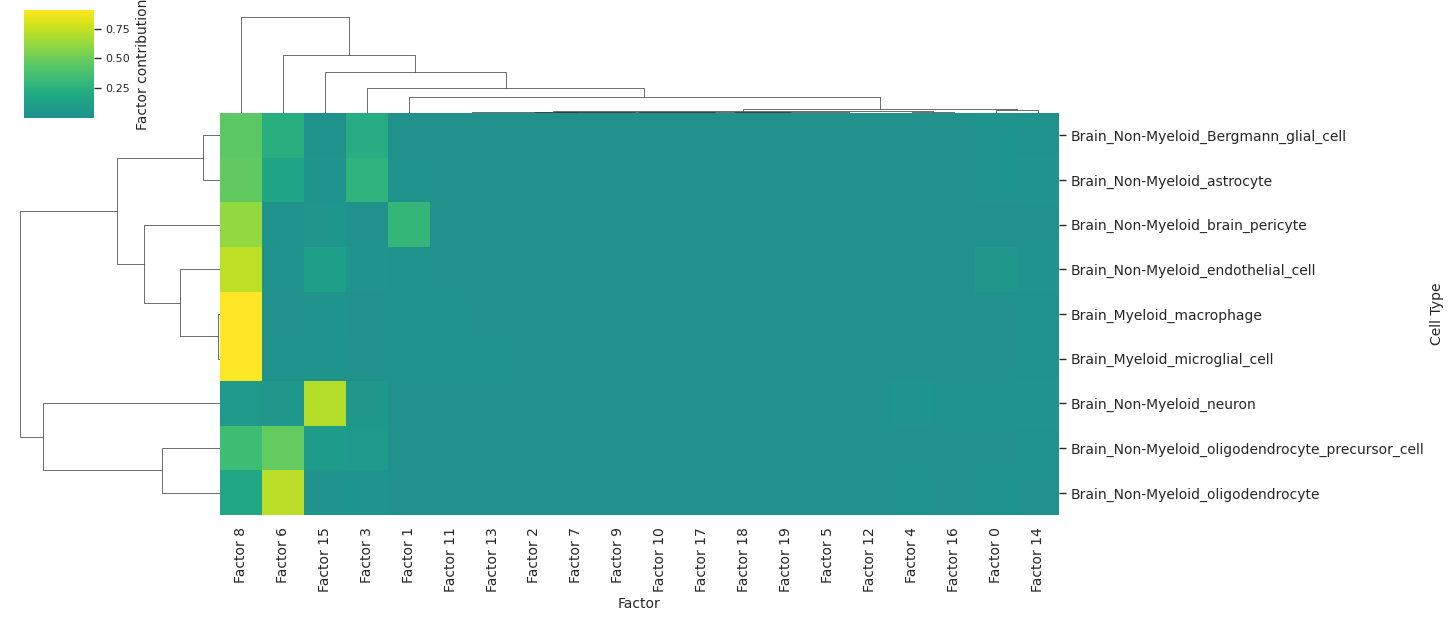

In [121]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(14, 6),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )
# increase font of everything 
cluster.ax_heatmap.tick_params(labelsize=10)
cluster.ax_heatmap.set_xlabel('Factor', size=10)
cluster.ax_heatmap.set_ylabel('Cell Type', size=10)
cluster.cax.set_ylabel('Factor contribution', size=10)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [122]:
# what if we prune the factors that are very lowly expressed, can we still see clear seperation of cell types?

# look at pi 
conc

array(13.625701, dtype=float32)

In [123]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

array([0.02642969, 0.02852723, 0.02378615, 0.0339781 , 0.02282277,
       0.02308524, 0.04845061, 0.02149018, 0.5241737 , 0.01844407,
       0.01812021, 0.02242747, 0.01812662, 0.0232926 , 0.02970204,
       0.05021836, 0.02492857, 0.01486172, 0.01260972, 0.01452497],
      dtype=float32)

          pi     Factor
8   0.524174   Facotor8
15  0.050218  Facotor15
6   0.048451   Facotor6
3   0.033978   Facotor3
14  0.029702  Facotor14


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

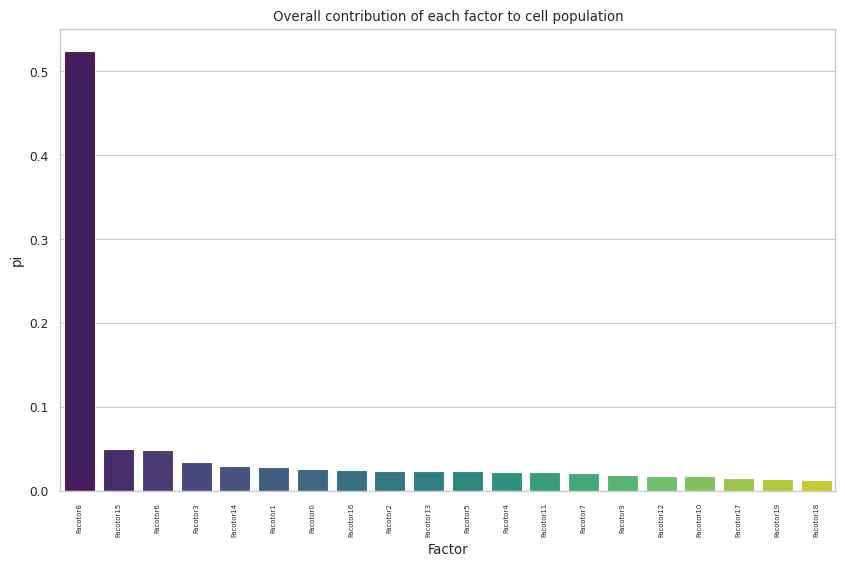

In [124]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")
